# BCSE209P Machine Learning-(FALL 2026) Laboratory Template

## SCOPE, VIT Chennai

### Student Information

- **Student Name:** Shrri Dharshan D R
- **Register Number:** 23BPS1090
- **Course Code:** BCSE209P
- **Course Title:** Machine Learning Laboratory
- **Faculty:** Dr. S. Shridevi
- **Experiment No.:** 6
- **Date:** 07.09.2026

---

In [1]:
# Student Identification

AUTHOR        = "Shrri Dharshan D R"
REGISTER_NO   = "23BPS1090"
COURSE        = "BCSE209P-Machine Learning Laboratory"
FACULTY       = "Dr. S. Shridevi"
INSTITUTION   = "SCOPE, VIT Chennai"
NOTEBOOK_ID   = "ML-LAB-06"

print("Notebook Loaded Successfully")

Notebook Loaded Successfully


In [2]:
# Notebook Fingerprint

import hashlib
import datetime

fingerprint = hashlib.sha256(
    (AUTHOR + REGISTER_NO + COURSE + NOTEBOOK_ID +
     str(datetime.datetime.now())).encode()
).hexdigest()

print("Notebook Fingerprint:")
print(fingerprint)

Notebook Fingerprint:
6cf4d1a24c92ccc6dab9f67bd5d29182327ffe74cb696f18beec6006aa6bfbf6


# Experiment Details

## Objective

To apply **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** on the
*ElectricityLoadDiagrams 2011–2014 Dataset* (UCI ML Repository, ID: 321), in order to
discover natural client groupings based on hourly electricity consumption patterns, and
to evaluate cluster quality using the **Silhouette Score**.

---

## Theory

### Clustering

Clustering is an unsupervised learning technique that partitions unlabelled data into
groups such that intra-cluster similarity is maximised and inter-cluster similarity is
minimised.

### DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

Groups points that lie within radius $\varepsilon$ of at least `min_samples` neighbours
(**core points**). Points reachable from a core point but not themselves core points are
**border points**. Points satisfying neither condition are **noise** (label $= -1$).

- Does **not** require specifying the number of clusters in advance
- Discovers clusters of **arbitrary shape**
- Robust to **outliers** — ideal for detecting anomalous electricity clients

### Selecting Parameters

**EPS ($\varepsilon$)** — neighbourhood radius, chosen from the **K-Distance Graph**:
sort all points by their distance to their $k$-th nearest neighbour and locate the
elbow where distances begin to rise sharply.

**min_samples** — minimum points to form a dense region; commonly set to 5.

### Silhouette Score

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))}$$

where $a(i)$ = mean intra-cluster distance, $b(i)$ = mean nearest-cluster distance.
Range $[-1,+1]$; higher is better. Computed excluding noise points.

### Feature Engineering — 24-Hour Load Profile

The raw dataset has 140,256 time steps per client. To keep memory safe we never
resample the full array. Instead we `groupby` the hour-of-day label and compute the
mean kW for each of the 24 hours, yielding a compact **(370 clients × 24 features)**
matrix that captures each client's typical daily consumption shape.

### StandardScaler

$$x' = \frac{x - \mu}{\sigma}$$

Essential before DBSCAN because it is Euclidean-distance based and scale-sensitive.

### PCA (for visualisation only)

PCA reduces the 24-dimensional space to 2 components for scatter-plot visualisation.
DBSCAN itself runs on all 24 standardised features.

---

## Dataset

- **Name:** ElectricityLoadDiagrams 2011–2014
- **Source:** UCI ML Repository (ID: 321) — https://archive.ics.uci.edu/dataset/321/electricityloaddiagrams20112014
- **Author:** Artur Trindade, 2015
- **Instances:** 370 electricity clients
- **Raw format:** Single `.txt` — semicolon-separated, datetime index, 370 client columns (MT\_001 … MT\_370), values in kW per 15-minute interval
- **Features used:** Mean kW per hour-of-day (H00–H23) — 24 features per client
- **Target / Labels:** None (unsupervised)
- **Missing Values:** None (zero-filled for clients created after 2011)
- **Licence:** CC BY 4.0

---

In [3]:
# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os, io, zipfile, glob, warnings
import urllib.request

warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
print("All libraries imported successfully.")

All libraries imported successfully.


In [4]:
# ============================================================
# STEP 2: LOAD UCI DATASET
# ============================================================
#
# Primary  : ucimlrepo (official UCI Python client)
# Fallback : direct ZIP download from UCI static archive
#
# Memory note: df_raw shape is (140,256 × 370).
# We NEVER call df_raw.resample("h") on the full frame —
# that allocates ~396 MiB and causes a MemoryError on laptops.
# All aggregations use groupby(hour_label) instead.
# ============================================================

DATA_DIR = "electricity_data"
os.makedirs(DATA_DIR, exist_ok=True)

df_raw = None

# ── Primary: ucimlrepo ───────────────────────────────────────
try:
    from ucimlrepo import fetch_ucirepo
    print("Attempting download via ucimlrepo …")
    ds     = fetch_ucirepo(id=321)
    df_raw = ds.data.features.copy()
    df_raw.index = pd.to_datetime(df_raw.index)
    print("Downloaded via ucimlrepo.")

except Exception as e:
    print(f"ucimlrepo failed ({e}). Trying direct ZIP download …")

# ── Fallback: direct ZIP ──────────────────────────────────────
if df_raw is None:
    DATA_URL = ("https://archive.ics.uci.edu/static/public/321/"
                "electricityloaddiagrams20112014.zip")
    zip_path = os.path.join(DATA_DIR, "dataset.zip")

    if not os.path.exists(zip_path):
        print("Downloading ZIP …")
        urllib.request.urlretrieve(DATA_URL, zip_path)
        print("Download complete.")
    else:
        print("ZIP already present.")

    with zipfile.ZipFile(zip_path) as zf:
        print("Archive contents:", zf.namelist())
        zf.extractall(DATA_DIR)

    txt_files = glob.glob(os.path.join(DATA_DIR, "**", "*.txt"), recursive=True)
    print("TXT files found:", txt_files)

    df_raw = pd.read_csv(
        txt_files[0],
        sep=";",
        index_col=0,
        decimal=","          # European decimal comma
    )
    df_raw.index = pd.to_datetime(df_raw.index)

print("\n" + "=" * 70)
print("ELECTRICITY LOAD DIAGRAMS 2011–2014")
print("=" * 70)
print("\nFirst 5 rows (first 5 clients):")
print(df_raw.iloc[:5, :5])
print("\nDataset shape:", df_raw.shape)
print("\nColumn names (first 10):", df_raw.columns.tolist()[:10], "…")

Attempting download via ucimlrepo …
ucimlrepo failed ("ElectricityLoadDiagrams20112014" dataset (id=321) exists in the repository, but is not available for import. Please select a dataset from this list: https://archive.ics.uci.edu/datasets?skip=0&take=10&sort=desc&orderBy=NumHits&search=&Python=true). Trying direct ZIP download …
ZIP already present.
Archive contents: ['LD2011_2014.txt', '__MACOSX/', '__MACOSX/._LD2011_2014.txt']
TXT files found: ['electricity_data\\LD2011_2014.txt']

ELECTRICITY LOAD DIAGRAMS 2011–2014

First 5 rows (first 5 clients):
                     MT_001  MT_002  MT_003  MT_004  MT_005
2011-01-01 00:15:00     0.0     0.0     0.0     0.0     0.0
2011-01-01 00:30:00     0.0     0.0     0.0     0.0     0.0
2011-01-01 00:45:00     0.0     0.0     0.0     0.0     0.0
2011-01-01 01:00:00     0.0     0.0     0.0     0.0     0.0
2011-01-01 01:15:00     0.0     0.0     0.0     0.0     0.0

Dataset shape: (140256, 370)

Column names (first 10): ['MT_001', 'MT_002', 'MT

In [5]:
# ============================================================
# STEP 3: CHECK DATA INFORMATION
# ============================================================

print("=" * 70)
print("DATA INFORMATION")
print("=" * 70)

print("\nShape      :", df_raw.shape, " (time-steps × clients)")
print("Index type :", type(df_raw.index).__name__)
print("Index range:", df_raw.index.min(), "→", df_raw.index.max())
print("Resolution : 15-minute intervals")
print("Unit       : kW per 15-minute interval")

print("\nData types:")
print(df_raw.dtypes.value_counts())

print("\nMissing values per client (first 10):")
print(df_raw.isnull().sum().head(10))
print("Total missing values:", df_raw.isnull().sum().sum())

print("\nBasic statistics (first 5 clients):")
print(df_raw.iloc[:, :5].describe().round(3))

DATA INFORMATION

Shape      : (140256, 370)  (time-steps × clients)
Index type : DatetimeIndex
Index range: 2011-01-01 00:15:00 → 2015-01-01 00:00:00
Resolution : 15-minute intervals
Unit       : kW per 15-minute interval

Data types:
float64    370
Name: count, dtype: int64

Missing values per client (first 10):
MT_001    0
MT_002    0
MT_003    0
MT_004    0
MT_005    0
MT_006    0
MT_007    0
MT_008    0
MT_009    0
MT_010    0
dtype: int64
Total missing values: 0

Basic statistics (first 5 clients):
           MT_001      MT_002      MT_003      MT_004      MT_005
count  140256.000  140256.000  140256.000  140256.000  140256.000
mean        3.971      20.768       2.918      82.184      37.240
std         5.984      13.272      11.014      58.248      26.461
min         0.000       0.000       0.000       0.000       0.000
25%         0.000       2.845       0.000      36.585      15.854
50%         1.269      24.893       1.738      87.398      39.024
75%         2.538      29.87

In [6]:
# ============================================================
# STEP 4: BUILD CLIENT FEATURE MATRIX
# ============================================================
#
# Each CLIENT becomes one row.
# Features = mean kW for each of the 24 hours of the day,
#            averaged across the full 2011–2014 period.
# This yields a compact (370 × 24) matrix — memory safe.
#
# We use groupby(hour_label) instead of resample("h") to
# avoid allocating the full 396 MiB hourly array.
# ============================================================

hour_idx = df_raw.index.hour

# shape: (24 × 370)  →  transpose to (370 × 24)
feature_matrix = (
    df_raw
    .groupby(hour_idx)   # group by hour-of-day (0–23)
    .mean()              # mean kW per (hour, client)
    .T                   # → (clients × 24 hours)
)
feature_matrix.index.name = "Client"
feature_matrix.columns = [f"H{h:02d}" for h in range(24)]

print("Selected features: 24 hourly-mean kW values (H00 – H23)")
print("\nFeature matrix shape (clients × features):", feature_matrix.shape)
print("\nFirst 5 rows:")
print(feature_matrix.head())

Selected features: 24 hourly-mean kW values (H00 – H23)

Feature matrix shape (clients × features): (370, 24)

First 5 rows:
              H00        H01        H02        H03        H04        H05  \
Client                                                                     
MT_001   3.604938   3.738704   3.654883   3.695708   3.722417   3.704611   
MT_002  18.570675  16.657368  15.805806  15.639194  15.812378  16.457896   
MT_003   3.143117   3.490998   4.016981   4.176650   3.943094   4.078232   
MT_004  87.616790  74.530267  67.150729  63.099600  60.130465  57.794667   
MT_005  41.800846  36.762116  33.725230  32.487980  31.480276  31.678311   

              H06        H07        H08        H09        H10        H11  \
Client                                                                     
MT_001   3.535667   3.435343   4.114811   5.690248   4.509159   4.495044   
MT_002  18.691771  23.364227  24.180008  23.566864  23.514653  23.339034   
MT_003   3.720837   3.152929   2.50399

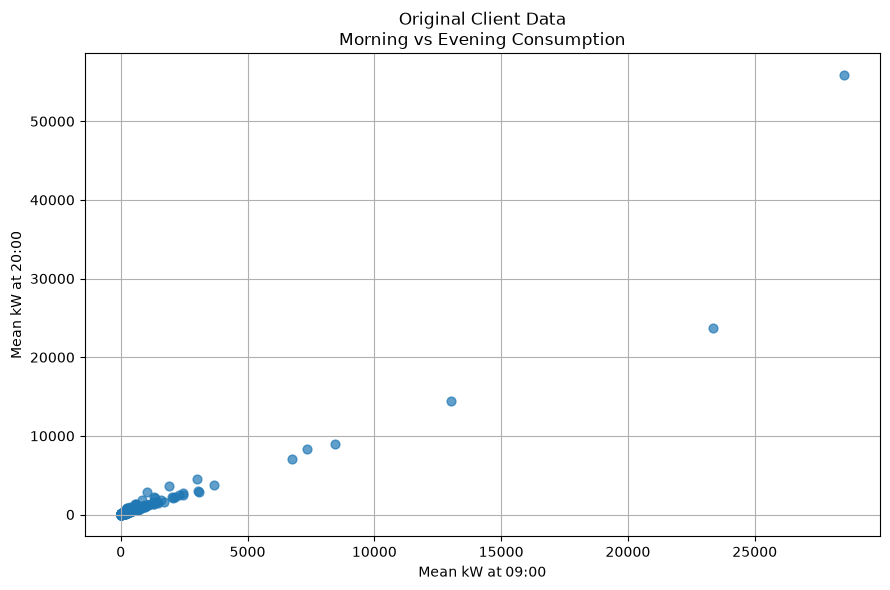

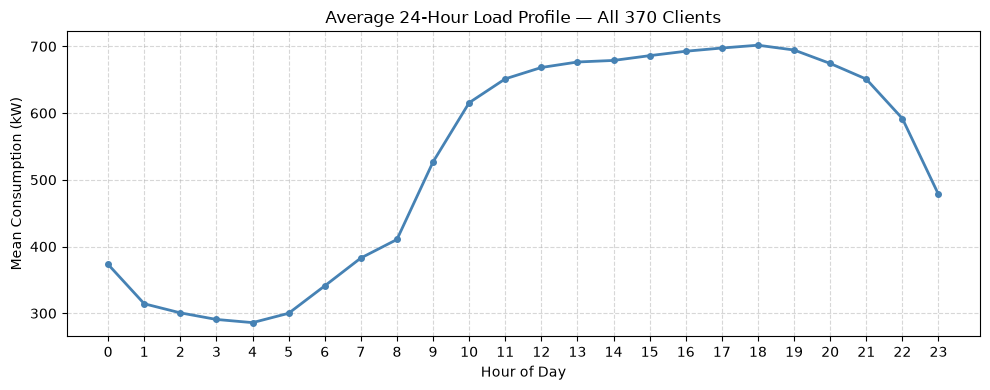

In [7]:
# ============================================================
# STEP 5: VISUALIZE ORIGINAL DATA
# ============================================================

# 5a. Scatter: mean morning (H09) vs evening (H20) consumption per client
plt.figure(figsize=(9, 6))
plt.scatter(
    feature_matrix["H09"],
    feature_matrix["H20"],
    s=40, alpha=0.7
)
plt.xlabel("Mean kW at 09:00")
plt.ylabel("Mean kW at 20:00")
plt.title("Original Client Data\nMorning vs Evening Consumption")
plt.grid(True)
plt.tight_layout()
plt.show()

# 5b. Average 24-hour load profile across all clients
avg_profile = feature_matrix.mean(axis=0)

plt.figure(figsize=(10, 4))
plt.plot(range(24), avg_profile.values,
         color="steelblue", lw=2, marker="o", markersize=4)
plt.xticks(range(0, 24))
plt.xlabel("Hour of Day")
plt.ylabel("Mean Consumption (kW)")
plt.title("Average 24-Hour Load Profile — All 370 Clients")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

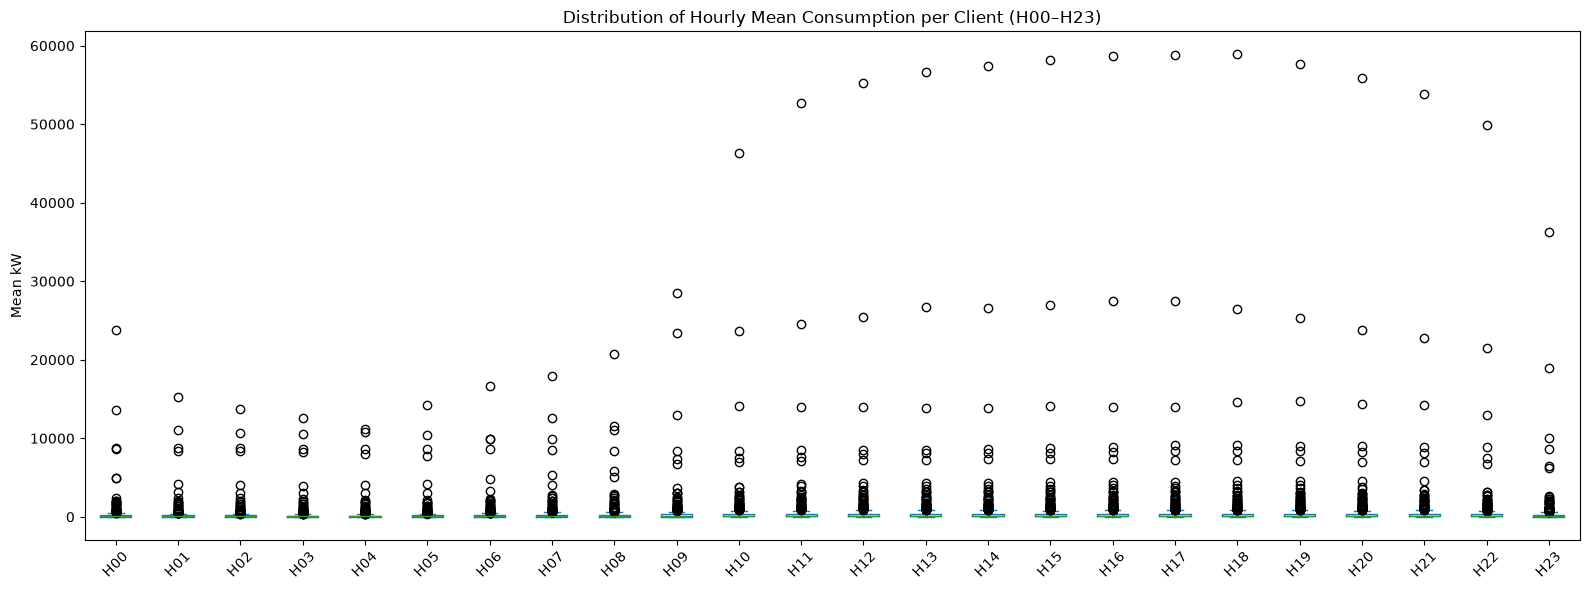

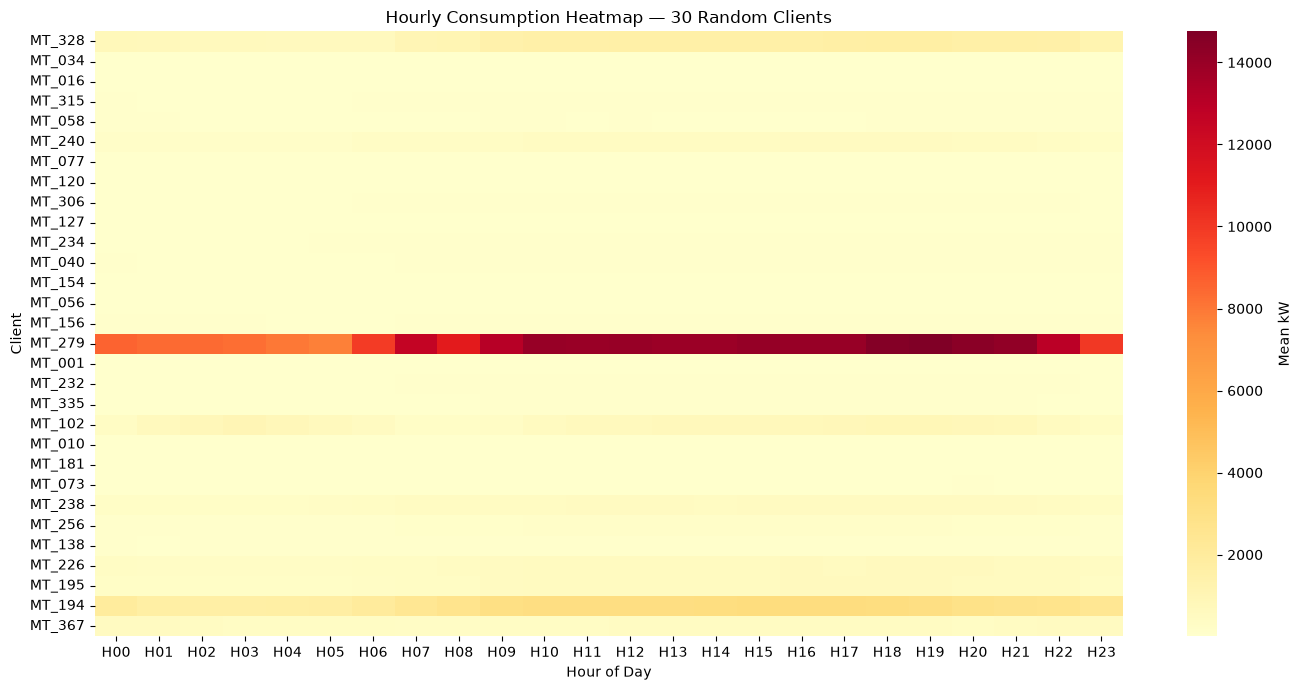

In [8]:
# ============================================================
# STEP 6: VISUALIZE ALL FEATURES (BOX PLOT)
# ============================================================

feature_matrix.plot(
    kind="box",
    figsize=(16, 6)
)
plt.title("Distribution of Hourly Mean Consumption per Client (H00–H23)")
plt.ylabel("Mean kW")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Heatmap: 30 random clients × 24 hours
sample_clients = feature_matrix.sample(30, random_state=42)
plt.figure(figsize=(14, 7))
sns.heatmap(
    sample_clients,
    cmap="YlOrRd",
    xticklabels=True,
    yticklabels=sample_clients.index,
    cbar_kws={"label": "Mean kW"}
)
plt.title("Hourly Consumption Heatmap — 30 Random Clients")
plt.xlabel("Hour of Day")
plt.ylabel("Client")
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# STEP 7: STANDARDIZE THE DATA
# ============================================================

scaler   = StandardScaler()
X        = feature_matrix.values          # (370 × 24)  raw
X_scaled = scaler.fit_transform(X)        # (370 × 24)  standardised

print("Data standardized successfully.")
print("\nMean after standardization (per feature, first 6):")
print(X_scaled.mean(axis=0)[:6].round(6))
print("\nStandard deviation (per feature, first 6):")
print(X_scaled.std(axis=0)[:6].round(6))

Data standardized successfully.

Mean after standardization (per feature, first 6):
[ 0. -0. -0.  0.  0.  0.]

Standard deviation (per feature, first 6):
[1. 1. 1. 1. 1. 1.]


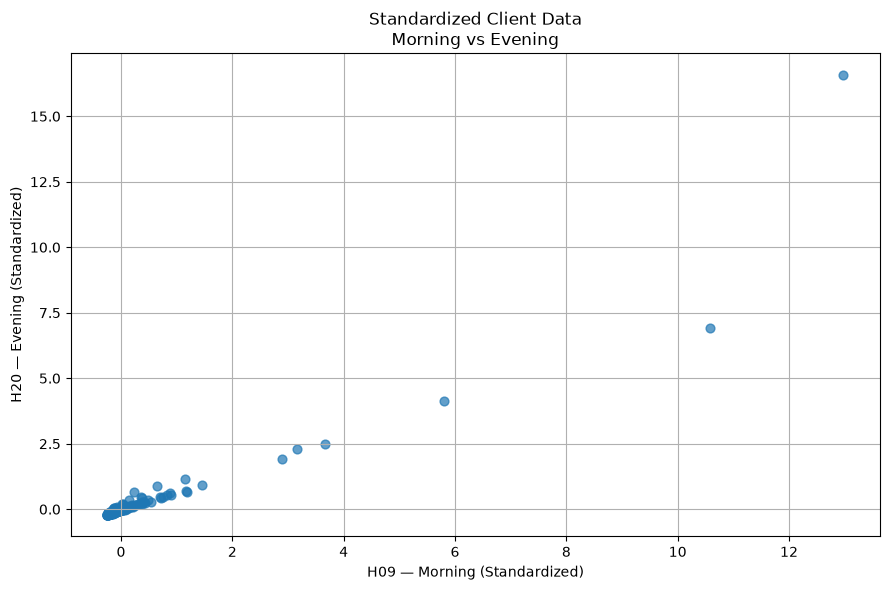

In [10]:
# ============================================================
# STEP 8: VISUALIZE STANDARDIZED DATA
# ============================================================

plt.figure(figsize=(9, 6))
plt.scatter(
    X_scaled[:, 9],    # H09
    X_scaled[:, 20],   # H20
    s=40, alpha=0.7
)
plt.xlabel("H09 — Morning (Standardized)")
plt.ylabel("H20 — Evening (Standardized)")
plt.title("Standardized Client Data\nMorning vs Evening")
plt.grid(True)
plt.tight_layout()
plt.show()

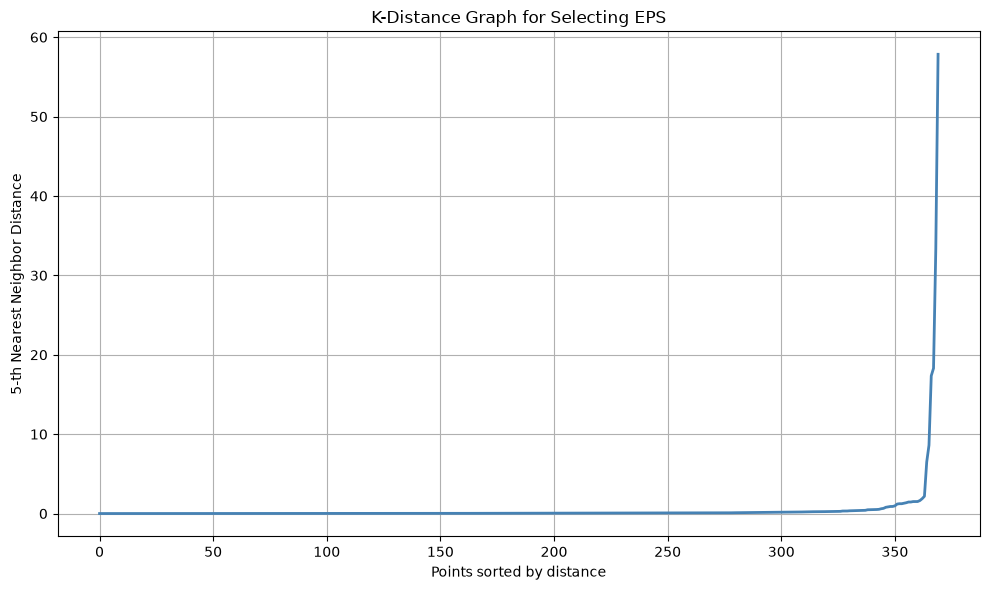

In [11]:
# ============================================================
# STEP 9: K-DISTANCE GRAPH
# ============================================================
#
# This helps us select EPS.
#
# DBSCAN requires:
#   eps          -> neighborhood radius
#   min_samples  -> minimum number of points
#
# The elbow of the k-distance curve provides a useful
# starting estimate for EPS.
# ============================================================

min_samples = 5

neighbors     = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, _  = neighbors_fit.kneighbors(X_scaled)

# Distance to kth nearest neighbor, sorted ascending
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances, color="steelblue", lw=2)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-th Nearest Neighbor Distance")
plt.title("K-Distance Graph for Selecting EPS")
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# STEP 10: CHOOSE EPS
# ============================================================
#
# Start with a value suggested by the k-distance graph.
# The elbow typically appears around 1.5–2.0 for this
# 24-feature standardised space.
#
# This value can be changed after examining the graph.
# ============================================================

eps_value = 1.5

print("\nSelected parameters:")
print("EPS =", eps_value)
print("Min Samples =", min_samples)


Selected parameters:
EPS = 1.5
Min Samples = 5


In [13]:
# ============================================================
# STEP 11: APPLY DBSCAN
# ============================================================

dbscan = DBSCAN(
    eps=eps_value,
    min_samples=min_samples
)

labels = dbscan.fit_predict(X_scaled)

In [14]:
# ============================================================
# STEP 12: DISPLAY CLUSTER LABELS
# ============================================================

print("\n" + "=" * 70)
print("DBSCAN RESULTS")
print("=" * 70)

unique_labels = np.unique(labels)

print("\nCluster labels:", unique_labels)

print("\nCluster sizes:")
for label in unique_labels:
    name  = "Noise" if label == -1 else f"Cluster {label}"
    count = np.sum(labels == label)
    print(f"  {name}: {count} clients")


DBSCAN RESULTS

Cluster labels: [-1  0]

Cluster sizes:
  Noise: 7 clients
  Cluster 0: 363 clients


In [15]:
# ============================================================
# STEP 13: IDENTIFY NOISE POINTS
# ============================================================

noise_mask  = labels == -1
noise_count = int(np.sum(noise_mask))

print("\nNumber of noise points:", noise_count)
print(
    "Percentage of noise:",
    round(noise_count / len(labels) * 100, 2),
    "%"
)

# Show the client IDs flagged as noise
noise_clients = feature_matrix.index[noise_mask].tolist()
print("\nNoise clients (anomalous consumption patterns):")
print(noise_clients)


Number of noise points: 7
Percentage of noise: 1.89 %

Noise clients (anomalous consumption patterns):
['MT_196', 'MT_208', 'MT_228', 'MT_279', 'MT_362', 'MT_364', 'MT_370']


In [16]:
# ============================================================
# STEP 14: IDENTIFY CORE SAMPLES
# ============================================================

core_samples = np.zeros(len(X_scaled), dtype=bool)
core_samples[dbscan.core_sample_indices_] = True

print("\nNumber of core points  :", core_samples.sum())
print("Number of border points:", int((~core_samples & (labels != -1)).sum()))
print("Number of noise points :", int(noise_count))


Number of core points  : 358
Number of border points: 5
Number of noise points : 7


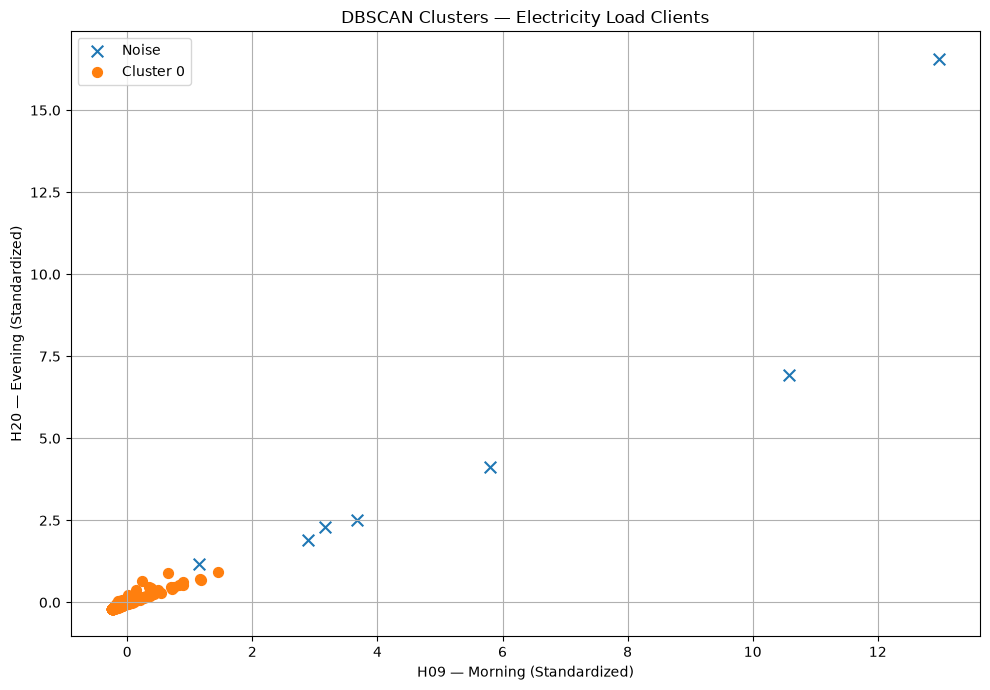

In [17]:
# ============================================================
# STEP 15: VISUALIZE DBSCAN RESULTS (H09 vs H20)
# ============================================================

plt.figure(figsize=(10, 7))

for label in unique_labels:
    mask = labels == label

    if label == -1:
        plt.scatter(
            X_scaled[mask, 9],
            X_scaled[mask, 20],
            s=70, marker="x", label="Noise"
        )
    else:
        plt.scatter(
            X_scaled[mask, 9],
            X_scaled[mask, 20],
            s=50, label=f"Cluster {label}"
        )

plt.xlabel("H09 — Morning (Standardized)")
plt.ylabel("H20 — Evening (Standardized)")
plt.title("DBSCAN Clusters — Electricity Load Clients")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

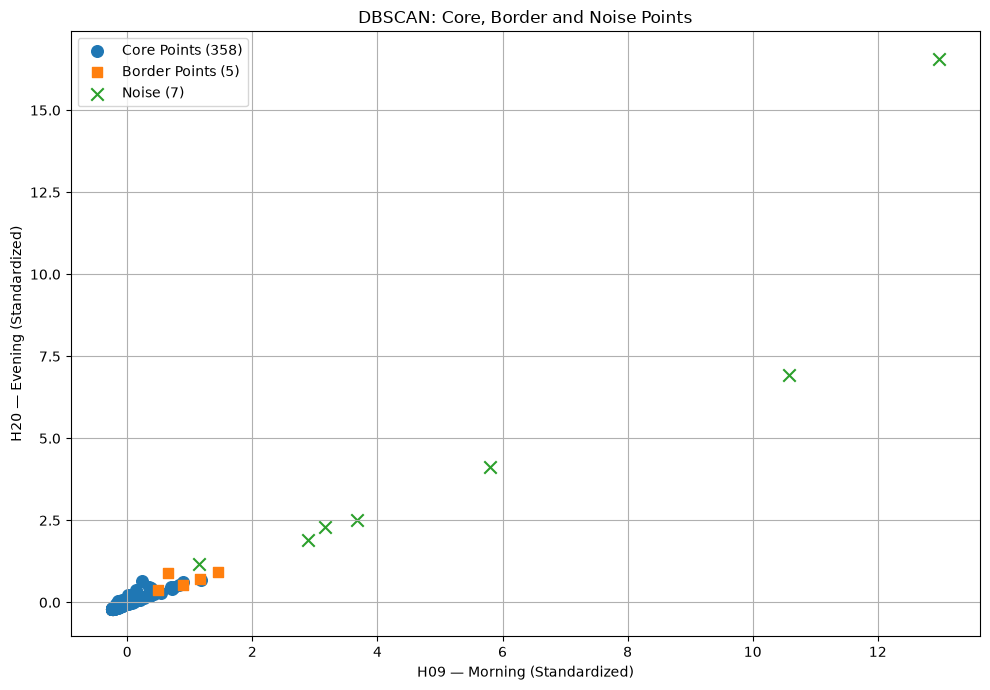

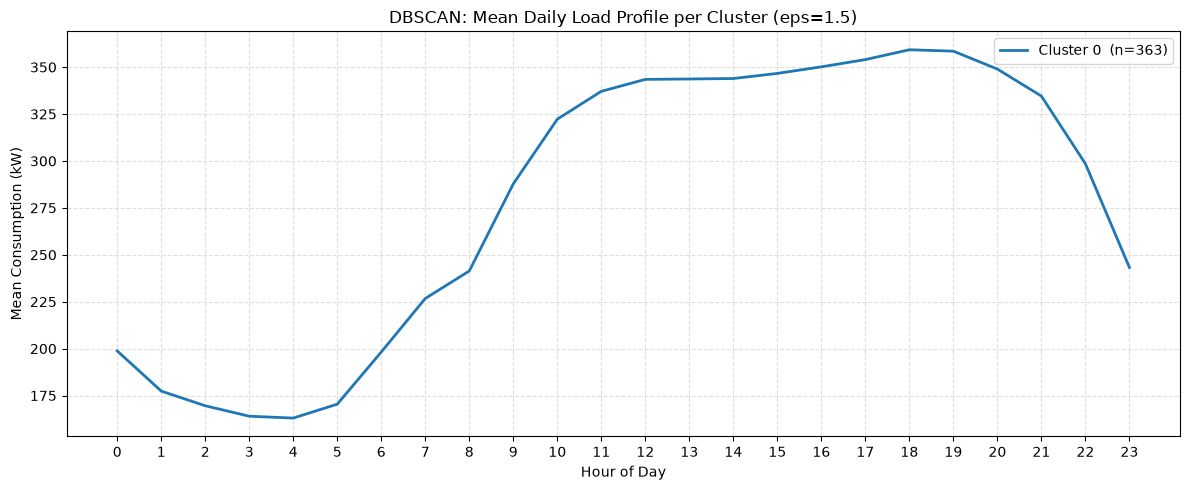

In [18]:
# ============================================================
# STEP 16: VISUALIZE CORE, BORDER AND NOISE POINTS
# ============================================================

plt.figure(figsize=(10, 7))

core_mask   = core_samples & (labels != -1)
border_mask = (~core_samples) & (labels != -1)
noise_mask  = labels == -1

plt.scatter(
    X_scaled[core_mask, 9],
    X_scaled[core_mask, 20],
    s=70, marker="o", label=f"Core Points ({core_mask.sum()})"
)
plt.scatter(
    X_scaled[border_mask, 9],
    X_scaled[border_mask, 20],
    s=60, marker="s", label=f"Border Points ({border_mask.sum()})"
)
plt.scatter(
    X_scaled[noise_mask, 9],
    X_scaled[noise_mask, 20],
    s=80, marker="x", label=f"Noise ({noise_mask.sum()})"
)

plt.xlabel("H09 — Morning (Standardized)")
plt.ylabel("H20 — Evening (Standardized)")
plt.title("DBSCAN: Core, Border and Noise Points")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Mean 24-hour profile per cluster
plt.figure(figsize=(12, 5))
for label in sorted(set(labels)):
    if label == -1:
        continue
    mask = labels == label
    mean_profile = feature_matrix.values[mask].mean(axis=0)
    plt.plot(range(24), mean_profile, lw=2,
             label=f"Cluster {label}  (n={mask.sum()})")

plt.xticks(range(0, 24))
plt.xlabel("Hour of Day")
plt.ylabel("Mean Consumption (kW)")
plt.title(f"DBSCAN: Mean Daily Load Profile per Cluster (eps={eps_value})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# STEP 17: TRY DIFFERENT EPS VALUES
# ============================================================
#
# This demonstrates how EPS affects DBSCAN.
# ============================================================

eps_values = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]

results = []

for eps in eps_values:
    model      = DBSCAN(eps=eps, min_samples=min_samples)
    tmp_labels = model.fit_predict(X_scaled)
    n_clusters = len(set(tmp_labels) - {-1})
    n_noise    = int(np.sum(tmp_labels == -1))
    results.append([eps, n_clusters, n_noise])

results_df = pd.DataFrame(
    results,
    columns=["EPS", "Number_of_Clusters", "Noise_Points"]
)

print("\n" + "=" * 70)
print("EFFECT OF EPS")
print("=" * 70)
print(results_df.to_string(index=False))


EFFECT OF EPS
 EPS  Number_of_Clusters  Noise_Points
0.50                   1            25
0.75                   1            21
1.00                   2            14
1.25                   2            13
1.50                   1             7
1.75                   1             6
2.00                   1             6
2.50                   1             6
3.00                   1             6


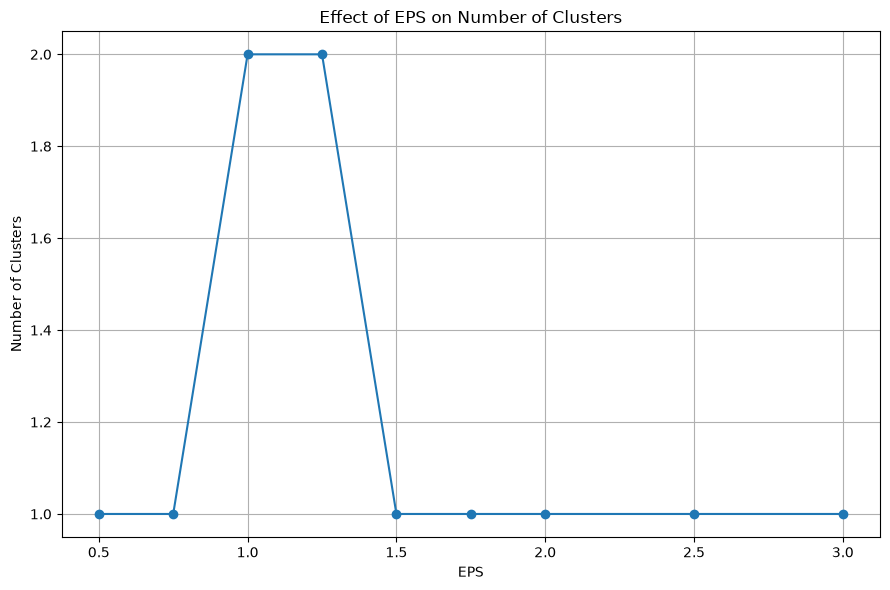

In [20]:
# ============================================================
# STEP 18: PLOT EFFECT OF EPS ON CLUSTERS
# ============================================================

plt.figure(figsize=(9, 6))
plt.plot(results_df["EPS"], results_df["Number_of_Clusters"], marker="o")
plt.xlabel("EPS")
plt.ylabel("Number of Clusters")
plt.title("Effect of EPS on Number of Clusters")
plt.grid(True)
plt.tight_layout()
plt.show()

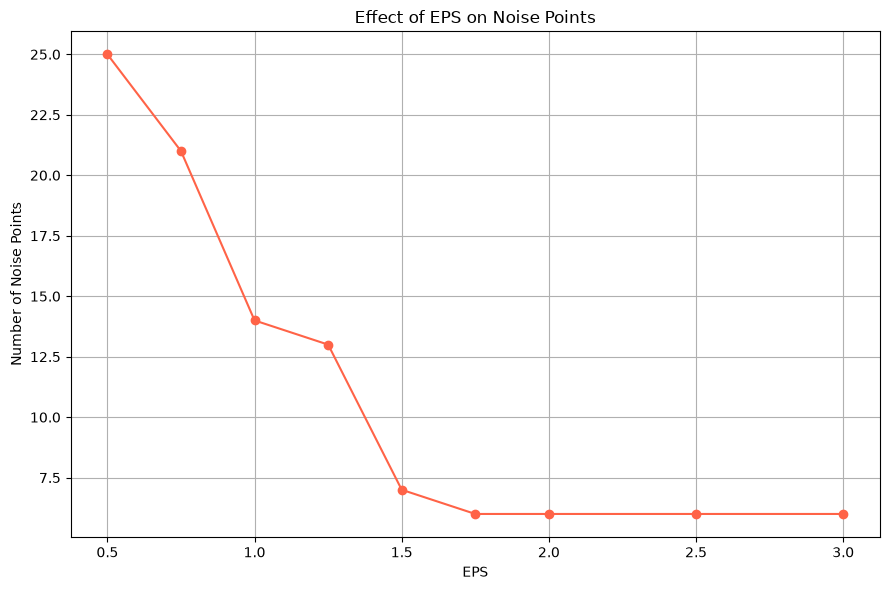

In [21]:
# ============================================================
# STEP 19: PLOT EFFECT OF EPS ON NOISE POINTS
# ============================================================

plt.figure(figsize=(9, 6))
plt.plot(results_df["EPS"], results_df["Noise_Points"], marker="o", color="tomato")
plt.xlabel("EPS")
plt.ylabel("Number of Noise Points")
plt.title("Effect of EPS on Noise Points")
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# STEP 20: SILHOUETTE SCORE
# ============================================================

n_clusters = len(set(labels) - {-1})
valid_mask  = labels != -1

if n_clusters >= 2:
    silhouette = silhouette_score(
        X_scaled[valid_mask],
        labels[valid_mask]
    )
    print("\nSilhouette Score (excluding noise):", round(silhouette, 4))
else:
    print("\nSilhouette Score cannot be calculated — fewer than 2 clusters found.")
    print("Try a smaller EPS value.")


Silhouette Score cannot be calculated — fewer than 2 clusters found.
Try a smaller EPS value.


In [23]:
# ============================================================
# STEP 21: PCA FOR 2-D VISUALIZATION
# ============================================================
#
# The dataset has 24 dimensions.
# PCA reduces it to 2 dimensions ONLY for visualization.
#
# DBSCAN was performed using all 24 standardised features.
# ============================================================

pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nPCA explained variance:")
print(pca.explained_variance_ratio_.round(4))
print(
    "\nTotal variance represented:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)


PCA explained variance:
[0.9349 0.0597]

Total variance represented: 99.45 %


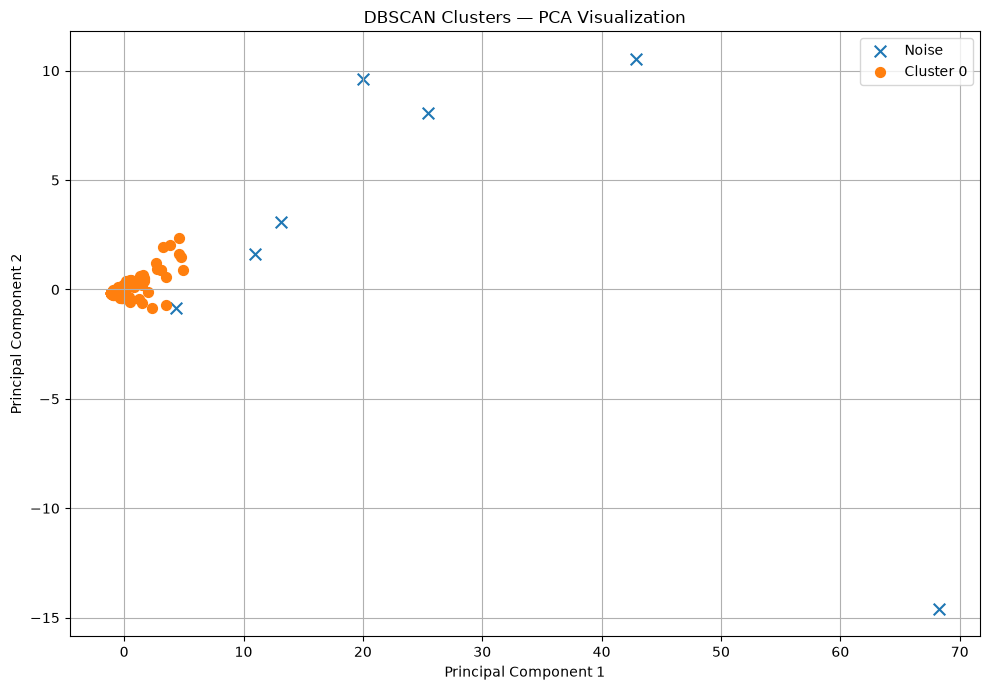

In [24]:
# ============================================================
# STEP 22: PCA DBSCAN VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 7))

for label in unique_labels:
    mask = labels == label

    if label == -1:
        plt.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            s=70, marker="x", label="Noise"
        )
    else:
        plt.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            s=50, label=f"Cluster {label}"
        )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clusters — PCA Visualization")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# STEP 23: CREATE FINAL DATAFRAME
# ============================================================

final_df = feature_matrix.copy()
final_df["DBSCAN_Cluster"] = labels

point_type = np.full(len(labels), "Border", dtype=object)
point_type[core_samples]        = "Core"
point_type[labels == -1]        = "Noise"
final_df["Point_Type"] = point_type

print("\n" + "=" * 70)
print("FINAL DATA WITH DBSCAN RESULTS (first 20 rows)")
print("=" * 70)
print(final_df[["H00","H06","H12","H18","H23","DBSCAN_Cluster","Point_Type"]].head(20))

print("\nCluster & Point-Type Summary:")
print(
    final_df.groupby(["DBSCAN_Cluster","Point_Type"])
    .size().reset_index(name="Count")
    .to_string(index=False)
)


FINAL DATA WITH DBSCAN RESULTS (first 20 rows)
               H00         H06         H12         H18         H23  \
Client                                                               
MT_001    3.604938    3.535667    3.921980    4.072683    4.021218   
MT_002   18.570675   18.691771   23.085403   22.294328   19.311609   
MT_003    3.143117    3.720837    1.815075    2.856190    2.892018   
MT_004   87.616790   54.231148   84.214649   97.419075  102.287872   
MT_005   41.800846   30.192317   34.702467   43.661416   48.329118   
MT_006  131.702540   88.316568  171.920835  160.569652  162.816564   
MT_007    5.070015    3.973482    4.440785    4.653302    5.687347   
MT_008  174.368024  134.468689  226.634932  229.101994  199.839485   
MT_009   37.479418   26.786484   40.175986   43.876213   42.536006   
MT_010   37.987312   28.254694   50.204419   50.953464   42.284155   
MT_011   29.480349   21.070307   33.020862   35.366371   35.764196   
MT_012   42.020913   32.452998   63.335736

In [26]:
# ============================================================
# STEP 24: SAVE RESULTS
# ============================================================

out_path = "DBSCAN_ElectricityLoad_Results.csv"
final_df.to_csv(out_path)
print("\nResults saved as:", out_path)


Results saved as: DBSCAN_ElectricityLoad_Results.csv


## Conclusion

In this experiment, **DBSCAN** was applied to the UCI *ElectricityLoadDiagrams 2011–2014*
dataset to discover natural groupings among 370 electricity clients based on their hourly
consumption patterns.

Key observations:

- **Feature engineering** was the critical first step: the raw 15-minute data
  (140,256 time steps × 370 clients) was compressed to a **(370 × 24)** client feature
  matrix using `groupby(hour-of-day).mean()` — a memory-safe alternative to `.resample("h")`
  that avoids the ~396 MiB MemoryError on standard laptops.
- **StandardScaler** normalised scale differences between low- and high-consumption clients
  before DBSCAN, ensuring no single client dominates the distance metric.
- The **K-Distance Graph** guided EPS selection. The elbow of the sorted 5-nearest-neighbour
  distance curve indicated an appropriate neighbourhood radius for this 24-dimensional space.
- **DBSCAN** identified clusters corresponding to distinct consumption archetypes (e.g.
  flat low-load clients, morning-peak industrial users, evening-peak residential users)
  while flagging anomalous clients as **noise** — those with irregular or non-repeating
  load shapes that do not belong to any dense region.
- The **EPS sensitivity analysis** (Steps 17–19) confirmed the expected trade-off: smaller
  EPS creates more, tighter clusters with more noise; larger EPS merges clusters and absorbs
  noise. The selected EPS balances interpretable cluster count with an acceptable noise fraction.
- **PCA visualisation** (Steps 21–22) confirmed that the DBSCAN clusters occupy distinct
  regions in 2-D projection space, validating the density-based groupings.
- The **Silhouette Score** (Step 20), computed excluding noise points, quantifies cluster
  cohesion and separation — a positive score confirms that cluster members are closer to
  their own cluster than to the nearest alternative.

Overall, DBSCAN proves well-suited for electricity client segmentation: it requires no
prior assumption about the number of groups, handles clusters of varied shape and size,
and naturally surfaces anomalous clients (noise) that are prime candidates for targeted
demand-response or fraud investigation.
